# Evaluation Notebook for CIDR 2027 Submission

In [2]:
# Imports

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np

from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.patches import Patch

#from __future__ import annotations

In [3]:
# Settings from Andreas Zimmerer
def apply_plot_params(
    fig_height: float,
    scale: float = 1.0,
    double_column: bool = False,
) -> None:
    """Apply the standard publication plot settings."""

    mpl.rcParams.update(
        {
            "figure.figsize": (
                (7.00697 if double_column else 3.3374) * scale,
                fig_height * scale,
            ),
            "figure.dpi": 300,
            "font.size": 11.0,
            "font.family": "serif",
            "axes.titlesize": "medium",
            "figure.titlesize": "medium",
            "text.usetex": True,
            "text.latex.preamble": (
                r"\usepackage{amsmath}"
                r"\usepackage{amssymb}"
                r"\usepackage{siunitx}[=v2]"
            ),
            "pgf.rcfonts": False,
            "pgf.texsystem": "pdflatex", 
        }
    )
    mpl.rcdefaults()
    mpl.rcParams["text.usetex"] = False


apply_plot_params(fig_height=2.5, scale=1.0, double_column=False)

## Evaluation 1 - Error Rates per SuT

In [ ]:
# Load CSV
df = pd.read_csv("./eval/sut_error_summary.csv")

# Optional: keep only summary rows
summary_df = df[df["pollution_group"] == "ALL"]

# -----------------------------
# Plot 1: Average Cell F1 Score
# -----------------------------
pivot_f1 = summary_df.pivot(
    index="sut",
    columns="dataset",
    values="avg_cell_f1"
)

plt.figure(figsize=(10, 6))
pivot_f1.plot(kind="bar")

plt.title("Average Cell F1 Score by SUT")
plt.ylabel("avg_cell_f1")
plt.xlabel("SUT")
plt.xticks(rotation=45)
plt.legend(title="Dataset")
plt.tight_layout()

plt.show()

# -----------------------------
# Plot 2: Error Rate
# -----------------------------
pivot_error = summary_df.pivot(
    index="sut",
    columns="dataset",
    values="error_rate"
)

plt.figure(figsize=(10, 6))
pivot_error.plot(kind="bar")

plt.title("Error Rate by SUT")
plt.ylabel("error_rate")
plt.xlabel("SUT")
plt.xticks(rotation=45)
plt.legend(title="Dataset")
plt.tight_layout()

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/eval/sut_error_summary.csv'

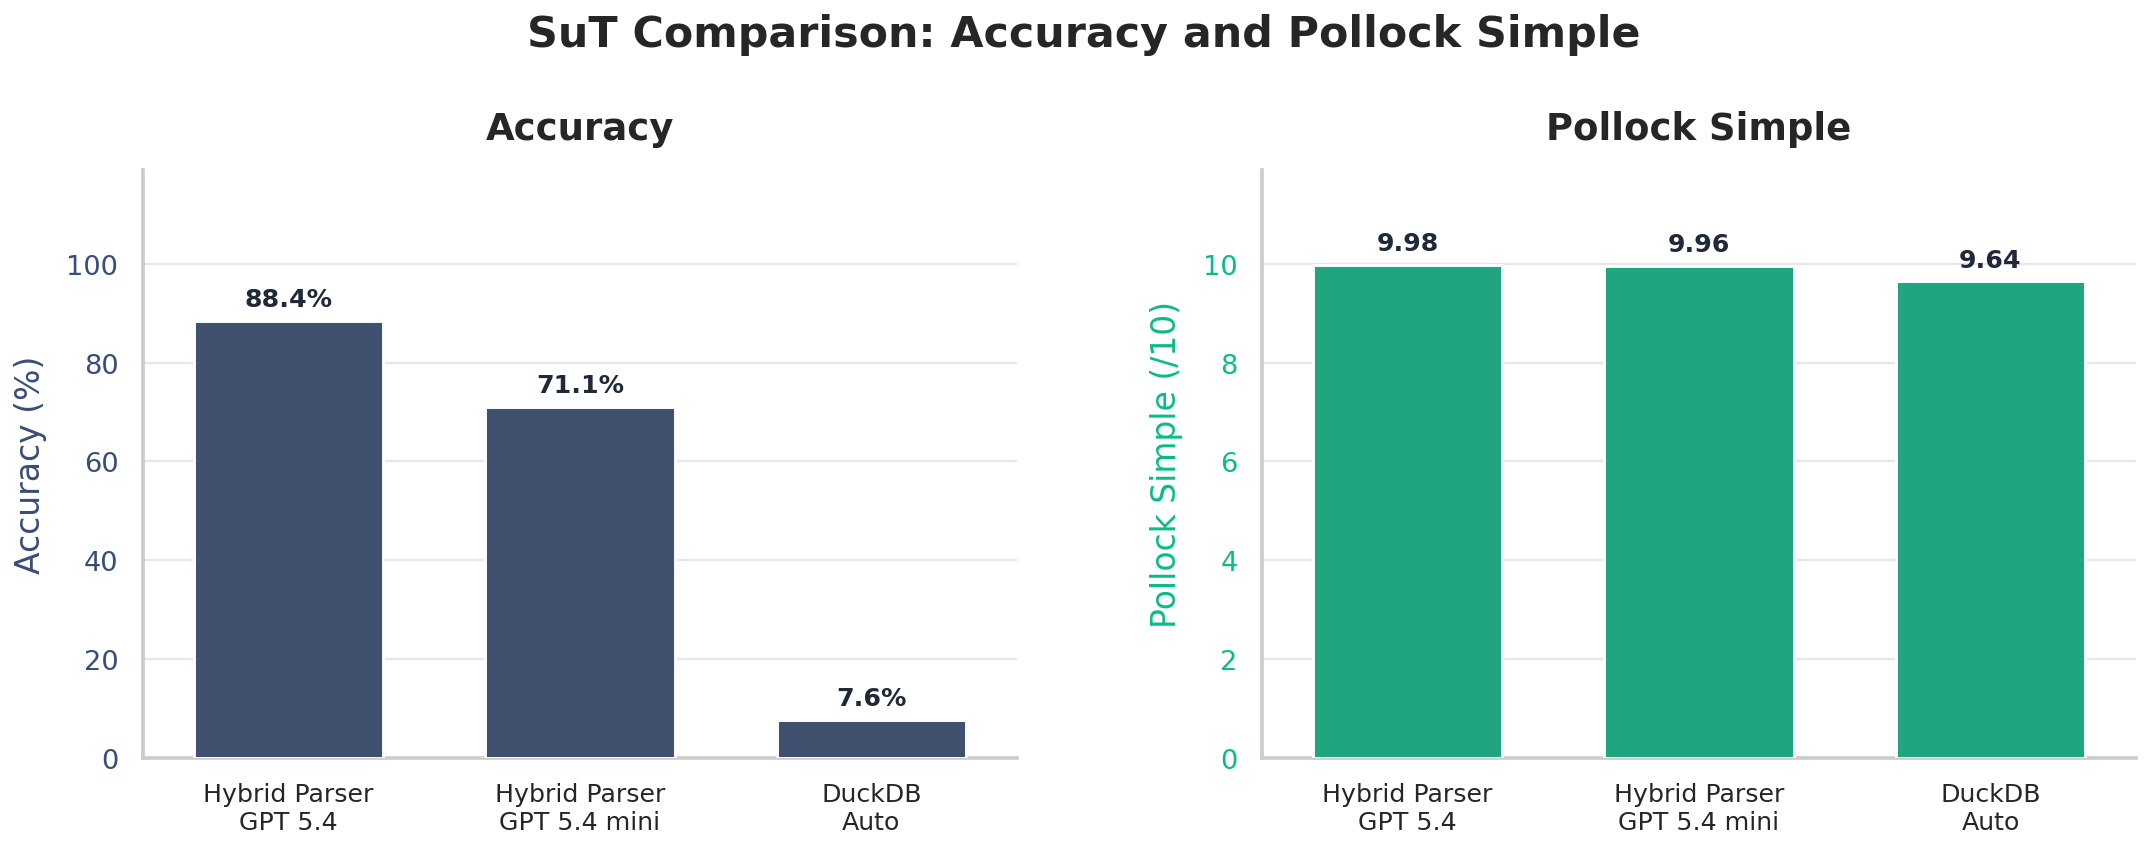

In [ ]:
def style_barplot_axis(
    ax: Axes,
    *,
    title: str,
    ylabel: str,
    color: str,
    y_limit: tuple[float, float],
) -> None:
    """Apply common styling to one barplot subplot."""

    ax.set_title(
        title,
        fontsize=19,
        fontweight="bold",
        pad=16,
    )

    ax.set_xlabel("")
    ax.set_ylabel(
        ylabel,
        color=color,
        fontsize=17,
        labelpad=10,
    )

    ax.set_ylim(*y_limit)

    ax.tick_params(
        axis="y",
        colors=color,
        labelsize=14,
    )
    ax.tick_params(
        axis="x",
        labelsize=13,
        rotation=0,
    )

    ax.set_axisbelow(True)
    ax.grid(
        axis="y",
        color="#E5E7EB",
        linewidth=1.2,
        zorder=0,
    )
    ax.grid(axis="x", visible=False)

    sns.despine(ax=ax)


def apply_plot_settings(
    fig: Figure,
    ax_accuracy: Axes,
    ax_pollock: Axes,
    *,
    accuracy_color: str = "#384E77",
    pollock_color: str = "#09BC8A",
    title: str = "SuT Comparison: Accuracy and Pollock Simple",
) -> None:
    """Apply figure-level and subplot-level settings."""

    fig.suptitle(
        title,
        fontsize=22,
        fontweight="bold",
        y=0.98,
    )

    style_barplot_axis(
        ax_accuracy,
        title="Accuracy",
        ylabel="Accuracy (%)",
        color=accuracy_color,
        y_limit=(0, 119),
    )

    style_barplot_axis(
        ax_pollock,
        title="Pollock Simple",
        ylabel="Pollock Simple (/10)",
        color=pollock_color,
        y_limit=(0, 11.9),
    )

    fig.subplots_adjust(
        left=0.08,
        right=0.97,
        bottom=0.22,
        top=0.82,
        wspace=0.28,
    )


def plot_sut_comparison(
    df: pd.DataFrame,
    *,
    sut_column: str = "SuT",
    accuracy_column: str = "accuracy_pct",
    pollock_column: str = "pollock_simple",
    accuracy_color: str = "#384E77",
    pollock_color: str = "#09BC8A",
    label_color: str = "#1F2937",
    bar_width: float = 0.65,
) -> tuple[Figure, Axes, Axes]:
    """Plot accuracy and Pollock scores in separate subplots."""

    required_columns = {
        sut_column,
        accuracy_column,
        pollock_column,
    }

    missing_columns = required_columns.difference(df.columns)

    if missing_columns:
        missing = ", ".join(sorted(missing_columns))
        raise ValueError(f"Missing required columns: {missing}")

    plot_df = df.copy()

    sns.set_theme(
        style="whitegrid",
        context="talk",
        rc={"text.usetex": False},
    )

    fig, (ax_accuracy, ax_pollock) = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(16, 7),
        dpi=140,
        sharex=True,
    )

    accuracy_bars = sns.barplot(
        data=plot_df,
        x=sut_column,
        y=accuracy_column,
        ax=ax_accuracy,
        color=accuracy_color,
        width=bar_width,
        errorbar=None,
        zorder=3,
    )

    pollock_bars = sns.barplot(
        data=plot_df,
        x=sut_column,
        y=pollock_column,
        ax=ax_pollock,
        color=pollock_color,
        width=bar_width,
        errorbar=None,
        zorder=3,
    )

    apply_plot_settings(
        fig,
        ax_accuracy,
        ax_pollock,
        accuracy_color=accuracy_color,
        pollock_color=pollock_color,
    )

    ax_accuracy.bar_label(
        accuracy_bars.containers[0],
        labels=[
            f"{value:.1f}%"
            for value in plot_df[accuracy_column]
        ],
        padding=5,
        fontsize=13,
        fontweight="bold",
        color=label_color,
    )

    ax_pollock.bar_label(
        pollock_bars.containers[0],
        labels=[
            f"{value:.2f}"
            for value in plot_df[pollock_column]
        ],
        padding=5,
        fontsize=13,
        fontweight="bold",
        color=label_color,
    )

    return fig, ax_accuracy, ax_pollock


df = pd.DataFrame(
    {
        "SuT": [
            "Hybrid Parser\nGPT 5.4",
            "Hybrid Parser\nGPT 5.4 mini",
            "DuckDB\nAuto",
        ],
        "accuracy_pct": [
            88.3893,
            71.0607,
            7.6386,
        ],
        "pollock_simple": [
            9.975212,
            9.962150,
            9.645,
        ],
    }
)


fig, ax_accuracy, ax_pollock = plot_sut_comparison(df)

plt.show()

### Error Rates for Top 5 Best Performing SuTs

In [ ]:
# Load CSV
df = pd.read_csv("sut_error_summary.csv")

# Remove aggregate rows
df = df[df["pollution_group"] != "ALL"]

# -----------------------------------
# Select Top 5 SUTs
# -----------------------------------
top_suts = (
    df.groupby("sut")["error_rate"]
    .mean()
    .sort_values()
    .head(5)
    .index
)

df = df[df["sut"].isin(top_suts)]

# -----------------------------------
# Pivot table
# -----------------------------------
pivot = df.pivot_table(
    index="pollution_group",
    columns="sut",
    values="error_rate",
    aggfunc="mean"
)

# -----------------------------------
# Remove pollution groups with no errors
# (all values are 0)
# -----------------------------------
pivot = pivot[(pivot > 0).any(axis=1)]

# -----------------------------------
# Sort by average error severity
# -----------------------------------
pivot["mean_error"] = pivot.mean(axis=1)
pivot = pivot.sort_values("mean_error", ascending=False)
pivot = pivot.drop(columns="mean_error")

# -----------------------------------
# Plot
# -----------------------------------
ax = pivot.plot(
    kind="bar",
    figsize=(18, 10)
)

plt.title("Top 5 SUTs: Error Rate by Pollution Type")
plt.ylabel("Error Rate")
plt.xlabel("Pollution / Error Type")

plt.xticks(rotation=75, ha="right")

plt.legend(
    title="SUT",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
#plt.savefig("error_rate_by_pollution.png", dpi=300)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'sut_error_summary.csv'

### Per System Error Analysis

In [ ]:
# Load CSV
df = pd.read_csv("sut_error_summary.csv")

# Remove aggregate rows
df = df[df["pollution_group"] != "ALL"]

# -----------------------------------
# Select Top 5 SUTs
# -----------------------------------
top_suts = (
    df.groupby("sut")["error_rate"]
    .mean()
    .sort_values()
    .head(5)
    .index
)

df = df[df["sut"].isin(top_suts)]

# -----------------------------------
# Create one histogram per SUT
# -----------------------------------
for sut in top_suts:

    sut_df = df[df["sut"] == sut].copy()

    # Remove rows where there are no poor files
    sut_df = sut_df[sut_df["poor_files"] > 0]

    # Sort by number of poor files
    sut_df = sut_df.sort_values("poor_files", ascending=False)

    # X positions
    x = np.arange(len(sut_df))

    # Figure
    plt.figure(figsize=(16, 7))

    # Background bars = total files
    plt.bar(
        x,
        sut_df["total_files"],
        alpha=0.35,
        label="Total Files"
    )

    # Foreground bars = poor files
    plt.bar(
        x,
        sut_df["poor_files"],
        label="Poor Files"
    )

    # Labels
    plt.xticks(
        x,
        sut_df["pollution_group"],
        rotation=75,
        ha="right"
    )

    plt.ylabel("Number of Files")
    plt.xlabel("Pollution / Error Type")

    plt.title(f"{sut}: Total vs Poor Files per Pollution Type")

    plt.legend()

    plt.tight_layout()
    plt.show()

## Evaluation 2 -- Statistics per Pollution Category

In [ ]:
# TODO: Heatmap per Pollution Category and top-SUTs 

In [ ]:
# TODO: Table of Correct / False Passes per SuT per Semantic vs. Syntax Type

In [ ]:
# TODO: 

## Evaluation 3 -- Runtime and Cost Arguments

In [ ]:
# TODO: calculate runtime and cost per SuT (LLM-based) and per file 